In [35]:
# ========================
# 1. Import Libraries
# ========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix


In [36]:
# ========================
# 2. Load Dataset
# ========================

import pandas as pd

# Update this path to where your file is stored in Drive
file_path = '/content/Dataset_ATS_v2.csv'

# Load the dataset
df = pd.read_csv(file_path)

# Display the first few rows to understand the structure of the data
print(df.head())


   gender  SeniorCitizen Dependents  tenure PhoneService MultipleLines  \
0  Female              0         No       1           No            No   
1    Male              0         No      41          Yes            No   
2  Female              0        Yes      52          Yes            No   
3  Female              0         No       1          Yes            No   
4    Male              0         No      67          Yes            No   

  InternetService        Contract  MonthlyCharges Churn  
0             DSL  Month-to-month              25   Yes  
1             DSL        One year              25    No  
2             DSL  Month-to-month              19    No  
3             DSL        One year              76   Yes  
4     Fiber optic  Month-to-month              51    No  


In [37]:
# 3. Detect Categorical Columns
# ========================
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns detected:", categorical_columns)

Categorical columns detected: ['gender', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'Contract', 'Churn']


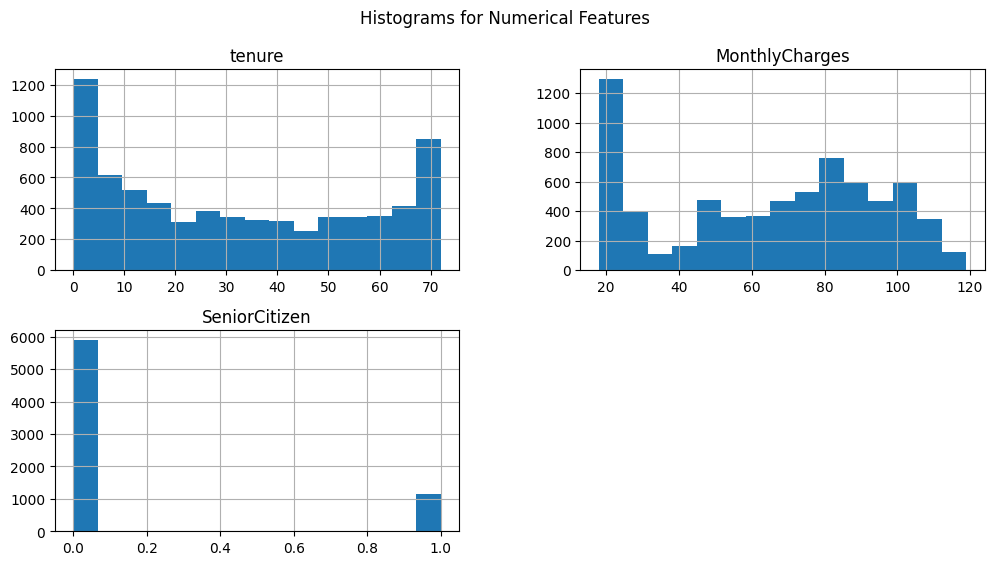

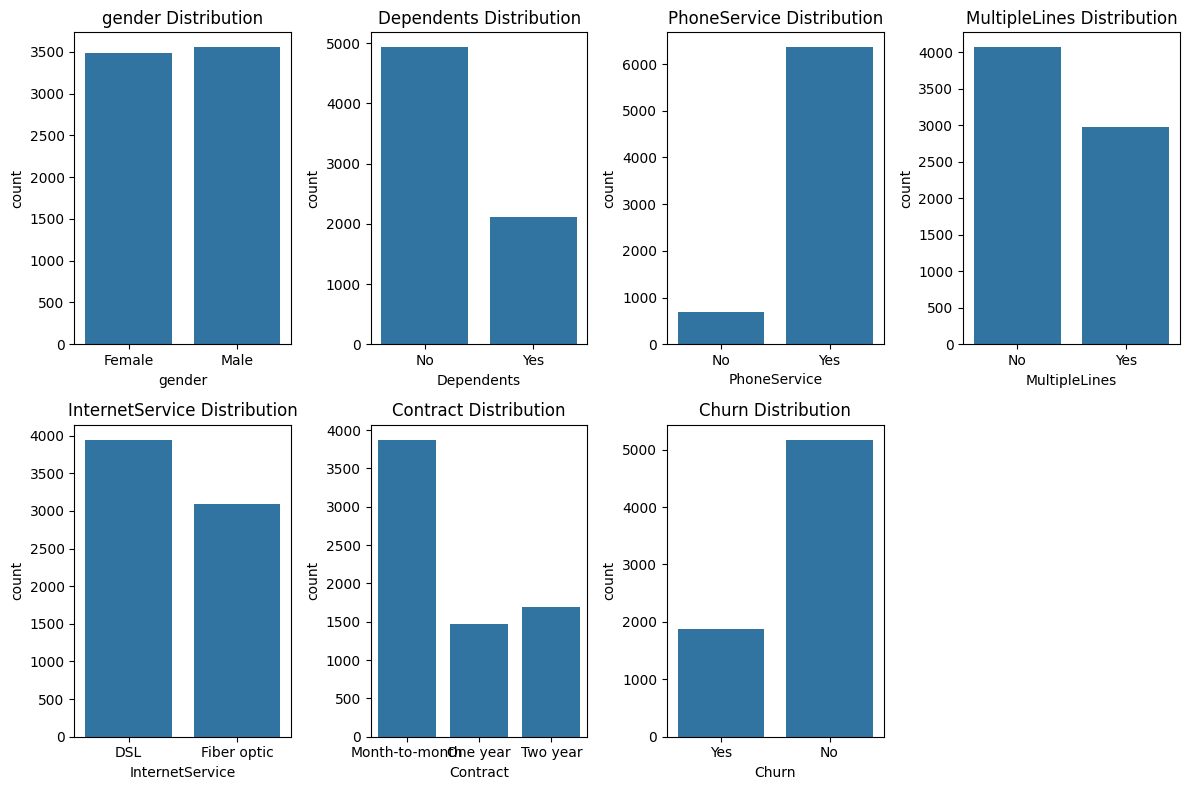

In [38]:
# Plot histogram for numerical variables
numerical_cols = ['tenure', 'MonthlyCharges', 'SeniorCitizen']
df[numerical_cols].hist(bins=15, figsize=(12, 6))
plt.suptitle("Histograms for Numerical Features")
plt.show()

# Visualize the distribution of encoded categorical columns
plt.figure(figsize=(12, 8))
for i, col in enumerate(categorical_columns, 1):
    plt.subplot(2, 4, i)
    sns.countplot(x=col, data=df)
    plt.title(f'{col} Distribution')
plt.tight_layout()
plt.show()

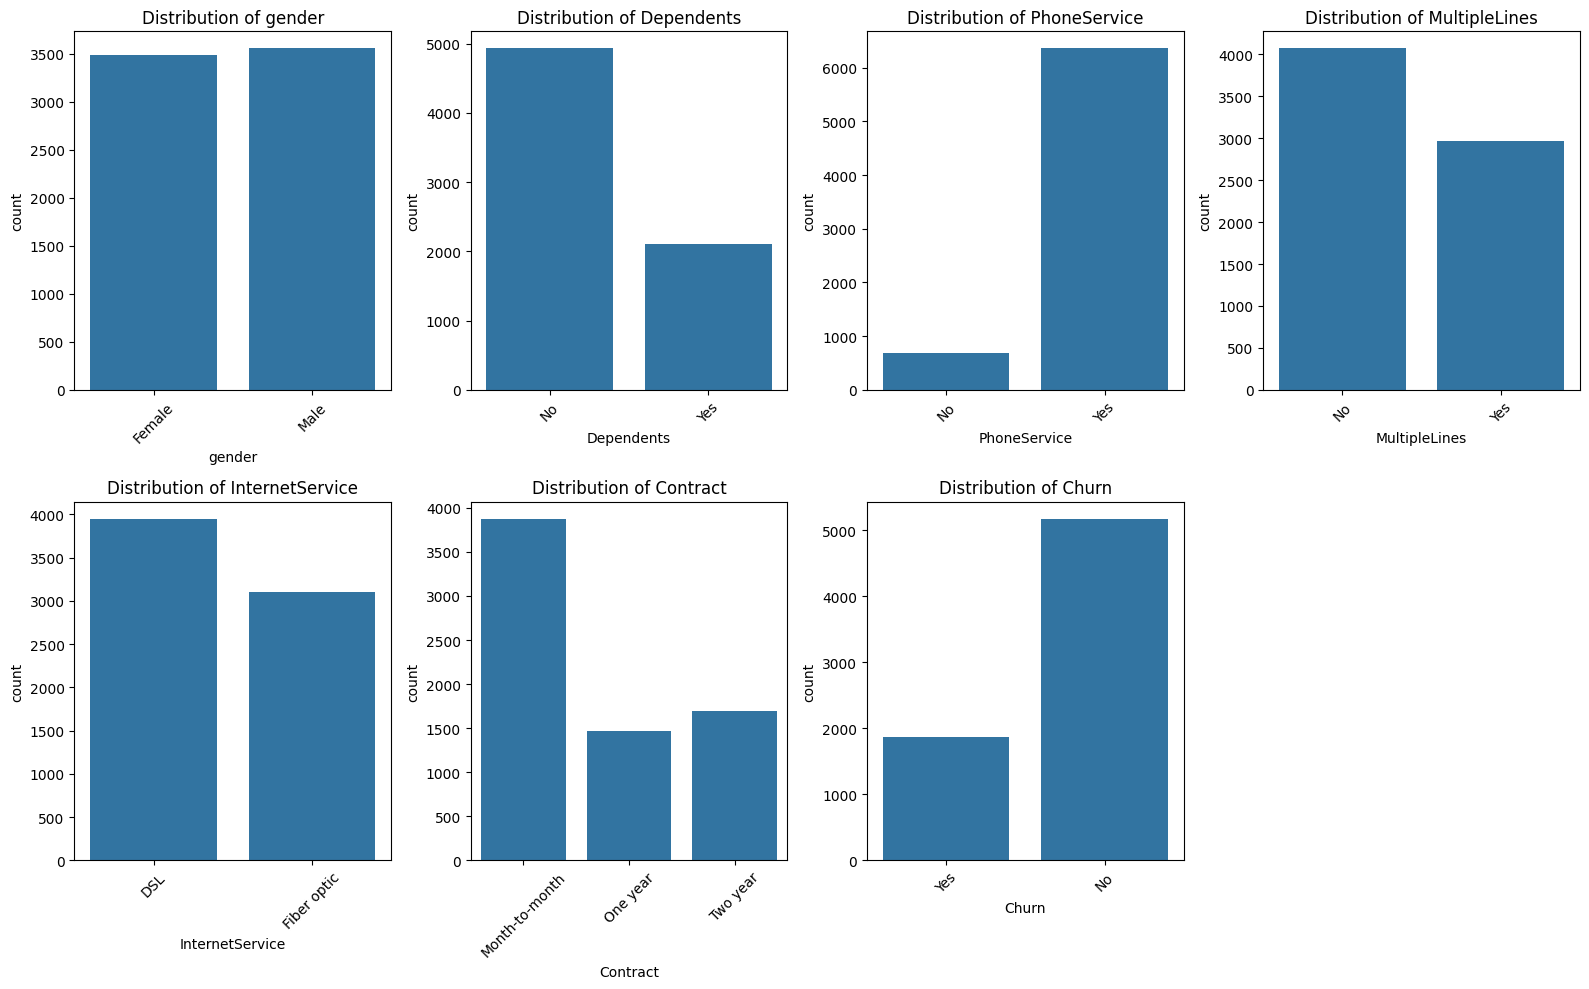

In [39]:
# 4. Visualize Categorical Columns
# ========================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 10))
for i, col in enumerate(categorical_columns, 1):
    plt.subplot(2, 4, i)  # Adjust rows/cols if you have more than 8 columns
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

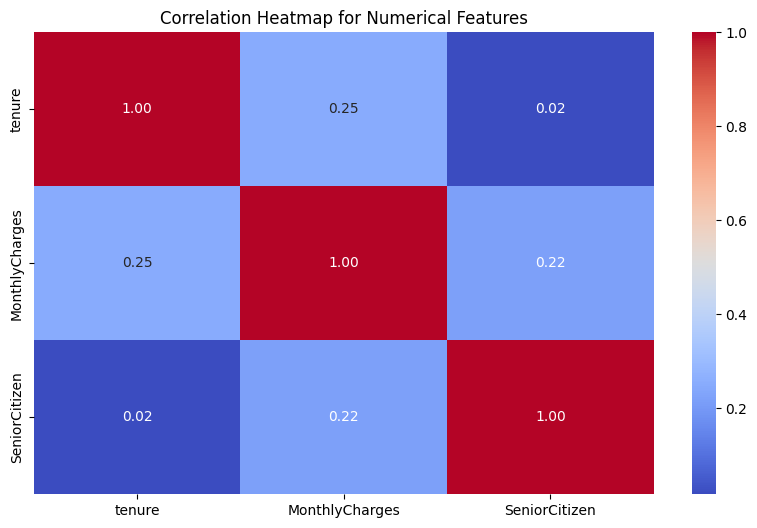

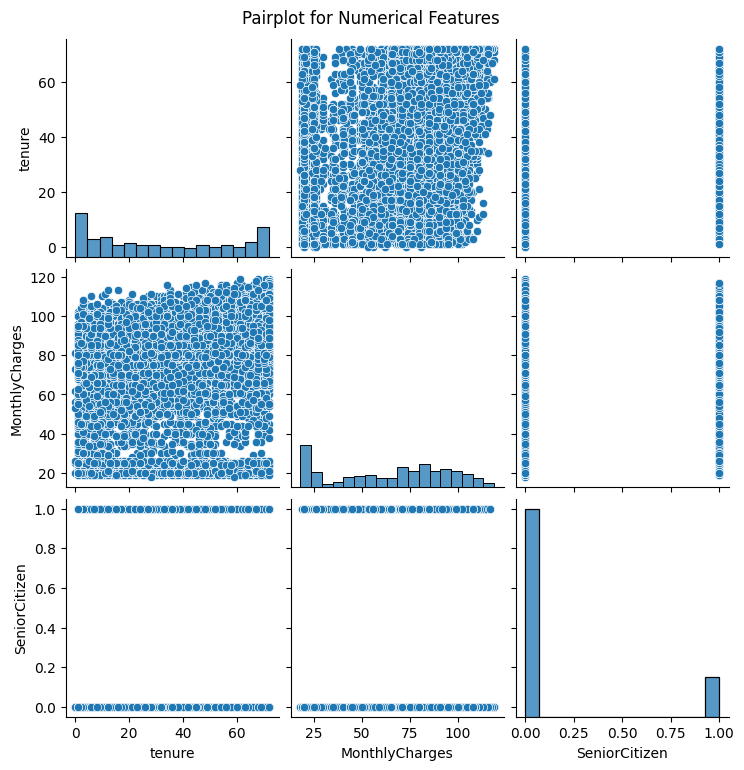

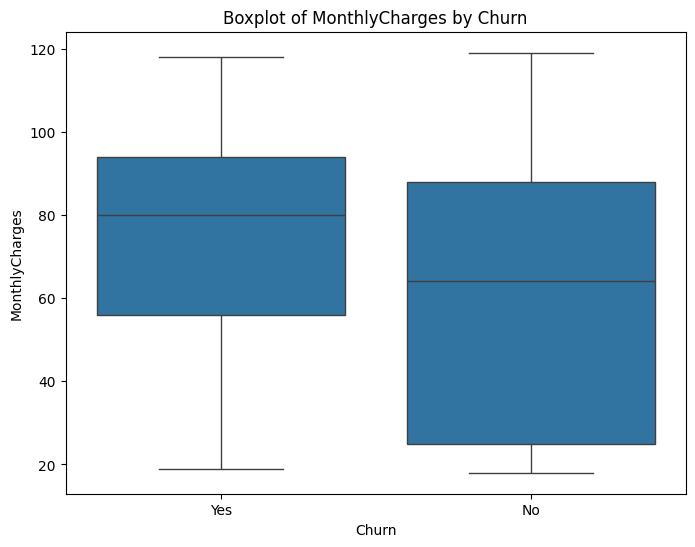

In [40]:
# ========================
# 5. Bivariate Analysis
# ========================

# Correlation heatmap for numerical variables
plt.figure(figsize=(10, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap for Numerical Features")
plt.show()

# Pairplot to visualize relationships between numerical variables
sns.pairplot(df[numerical_cols])
plt.suptitle("Pairplot for Numerical Features", y=1.02)
plt.show()

# Boxplot to compare 'MonthlyCharges' across 'Churn' (categorical feature)
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Boxplot of MonthlyCharges by Churn")
plt.show()

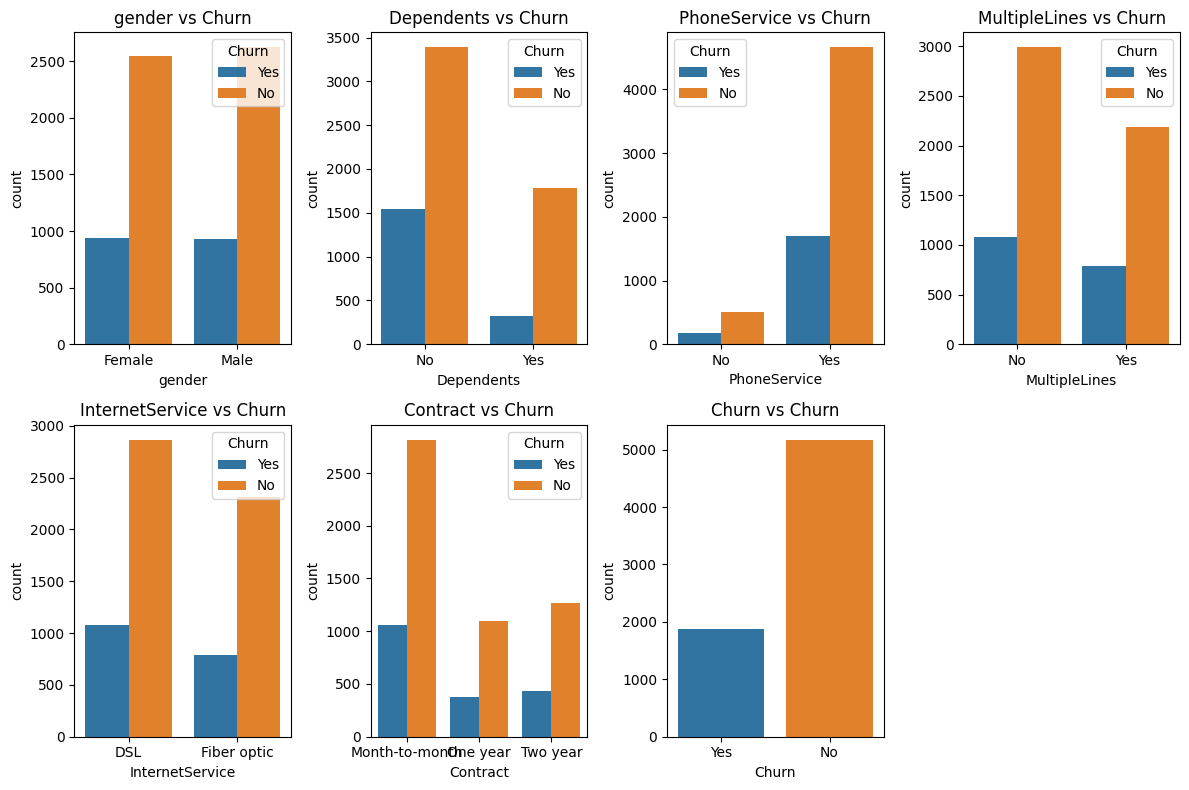

In [41]:
# ========================
# 6. Feature Relationships
# ========================

# Countplot for Churn vs. Categorical Features
plt.figure(figsize=(12, 8))
for i, col in enumerate(categorical_columns, 1):
    plt.subplot(2, 4, i)
    sns.countplot(x=col, hue='Churn', data=df)
    plt.title(f'{col} vs Churn')
plt.tight_layout()
plt.show()

In [42]:
# ========================
# 4. Encode Categorical Variables
# ========================

from sklearn.preprocessing import LabelEncoder

# Initialize the encoder
encoder = LabelEncoder()

# List of categorical columns to encode
categorical_columns = ['gender', 'PhoneService', 'MultipleLines', 'InternetService', 'Contract', 'Churn', 'Dependents', 'SeniorCitizen']

# Apply Label Encoding to each categorical column
for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

# Display the encoded dataset
print("\nEncoded Dataset:")
print(df.head())

df.info()

# Export cleaned dataset to CSV
df.to_csv('clean_Dataset_ATS_v2.csv', index=False)

print("Dataset successfully exported as clean_Dataset_ATS_v2.csv")


Encoded Dataset:
   gender  SeniorCitizen  Dependents  tenure  PhoneService  MultipleLines  \
0       0              0           0       1             0              0   
1       1              0           0      41             1              0   
2       0              0           1      52             1              0   
3       0              0           0       1             1              0   
4       1              0           0      67             1              0   

   InternetService  Contract  MonthlyCharges  Churn  
0                0         0              25      1  
1                0         1              25      0  
2                0         0              19      0  
3                0         1              76      1  
4                1         0              51      0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----


In [43]:
# ========================
# 7. K-Means Clustering with All Features
# ========================

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Use all columns for clustering (excluding 'Churn' column)
X_clustering = df.drop('Churn', axis=1)  # Exclude 'Churn' column for clustering

# Scaling the data for better clustering performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering)



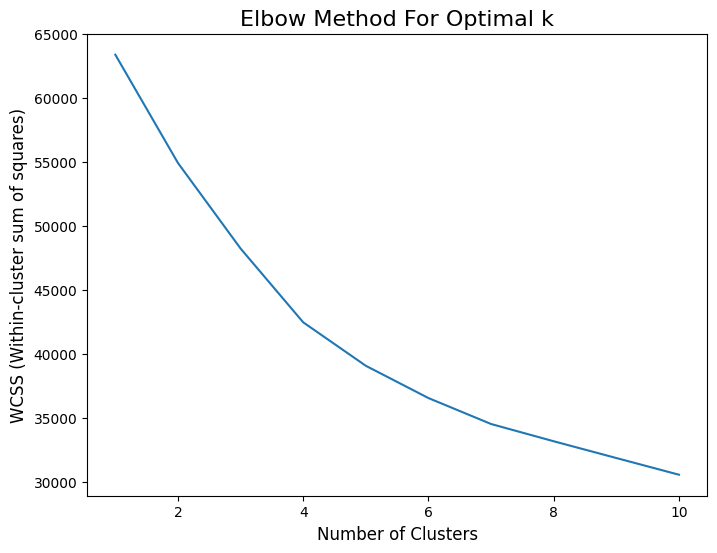

In [44]:
# ========================
# 8. Elbow Method for Optimal k
# ========================

# Find the optimal number of clusters using the Elbow Method
wcss = []  # List to store WCSS (Within-cluster sum of squares)
for i in range(1, 11):  # Try cluster numbers from 1 to 10
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)  # inertia_ is the WCSS

# Plotting the Elbow Method to find the optimal k
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss)
plt.title("Elbow Method For Optimal k", fontsize=16)
plt.xlabel("Number of Clusters", fontsize=12)
plt.ylabel("WCSS (Within-cluster sum of squares)", fontsize=12)
plt.show()


In [45]:
# ========================
# 9. Apply K-Means with Optimal k
# ========================

# Apply K-Means with the optimal k (based on the elbow plot, let's choose k=3)
kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

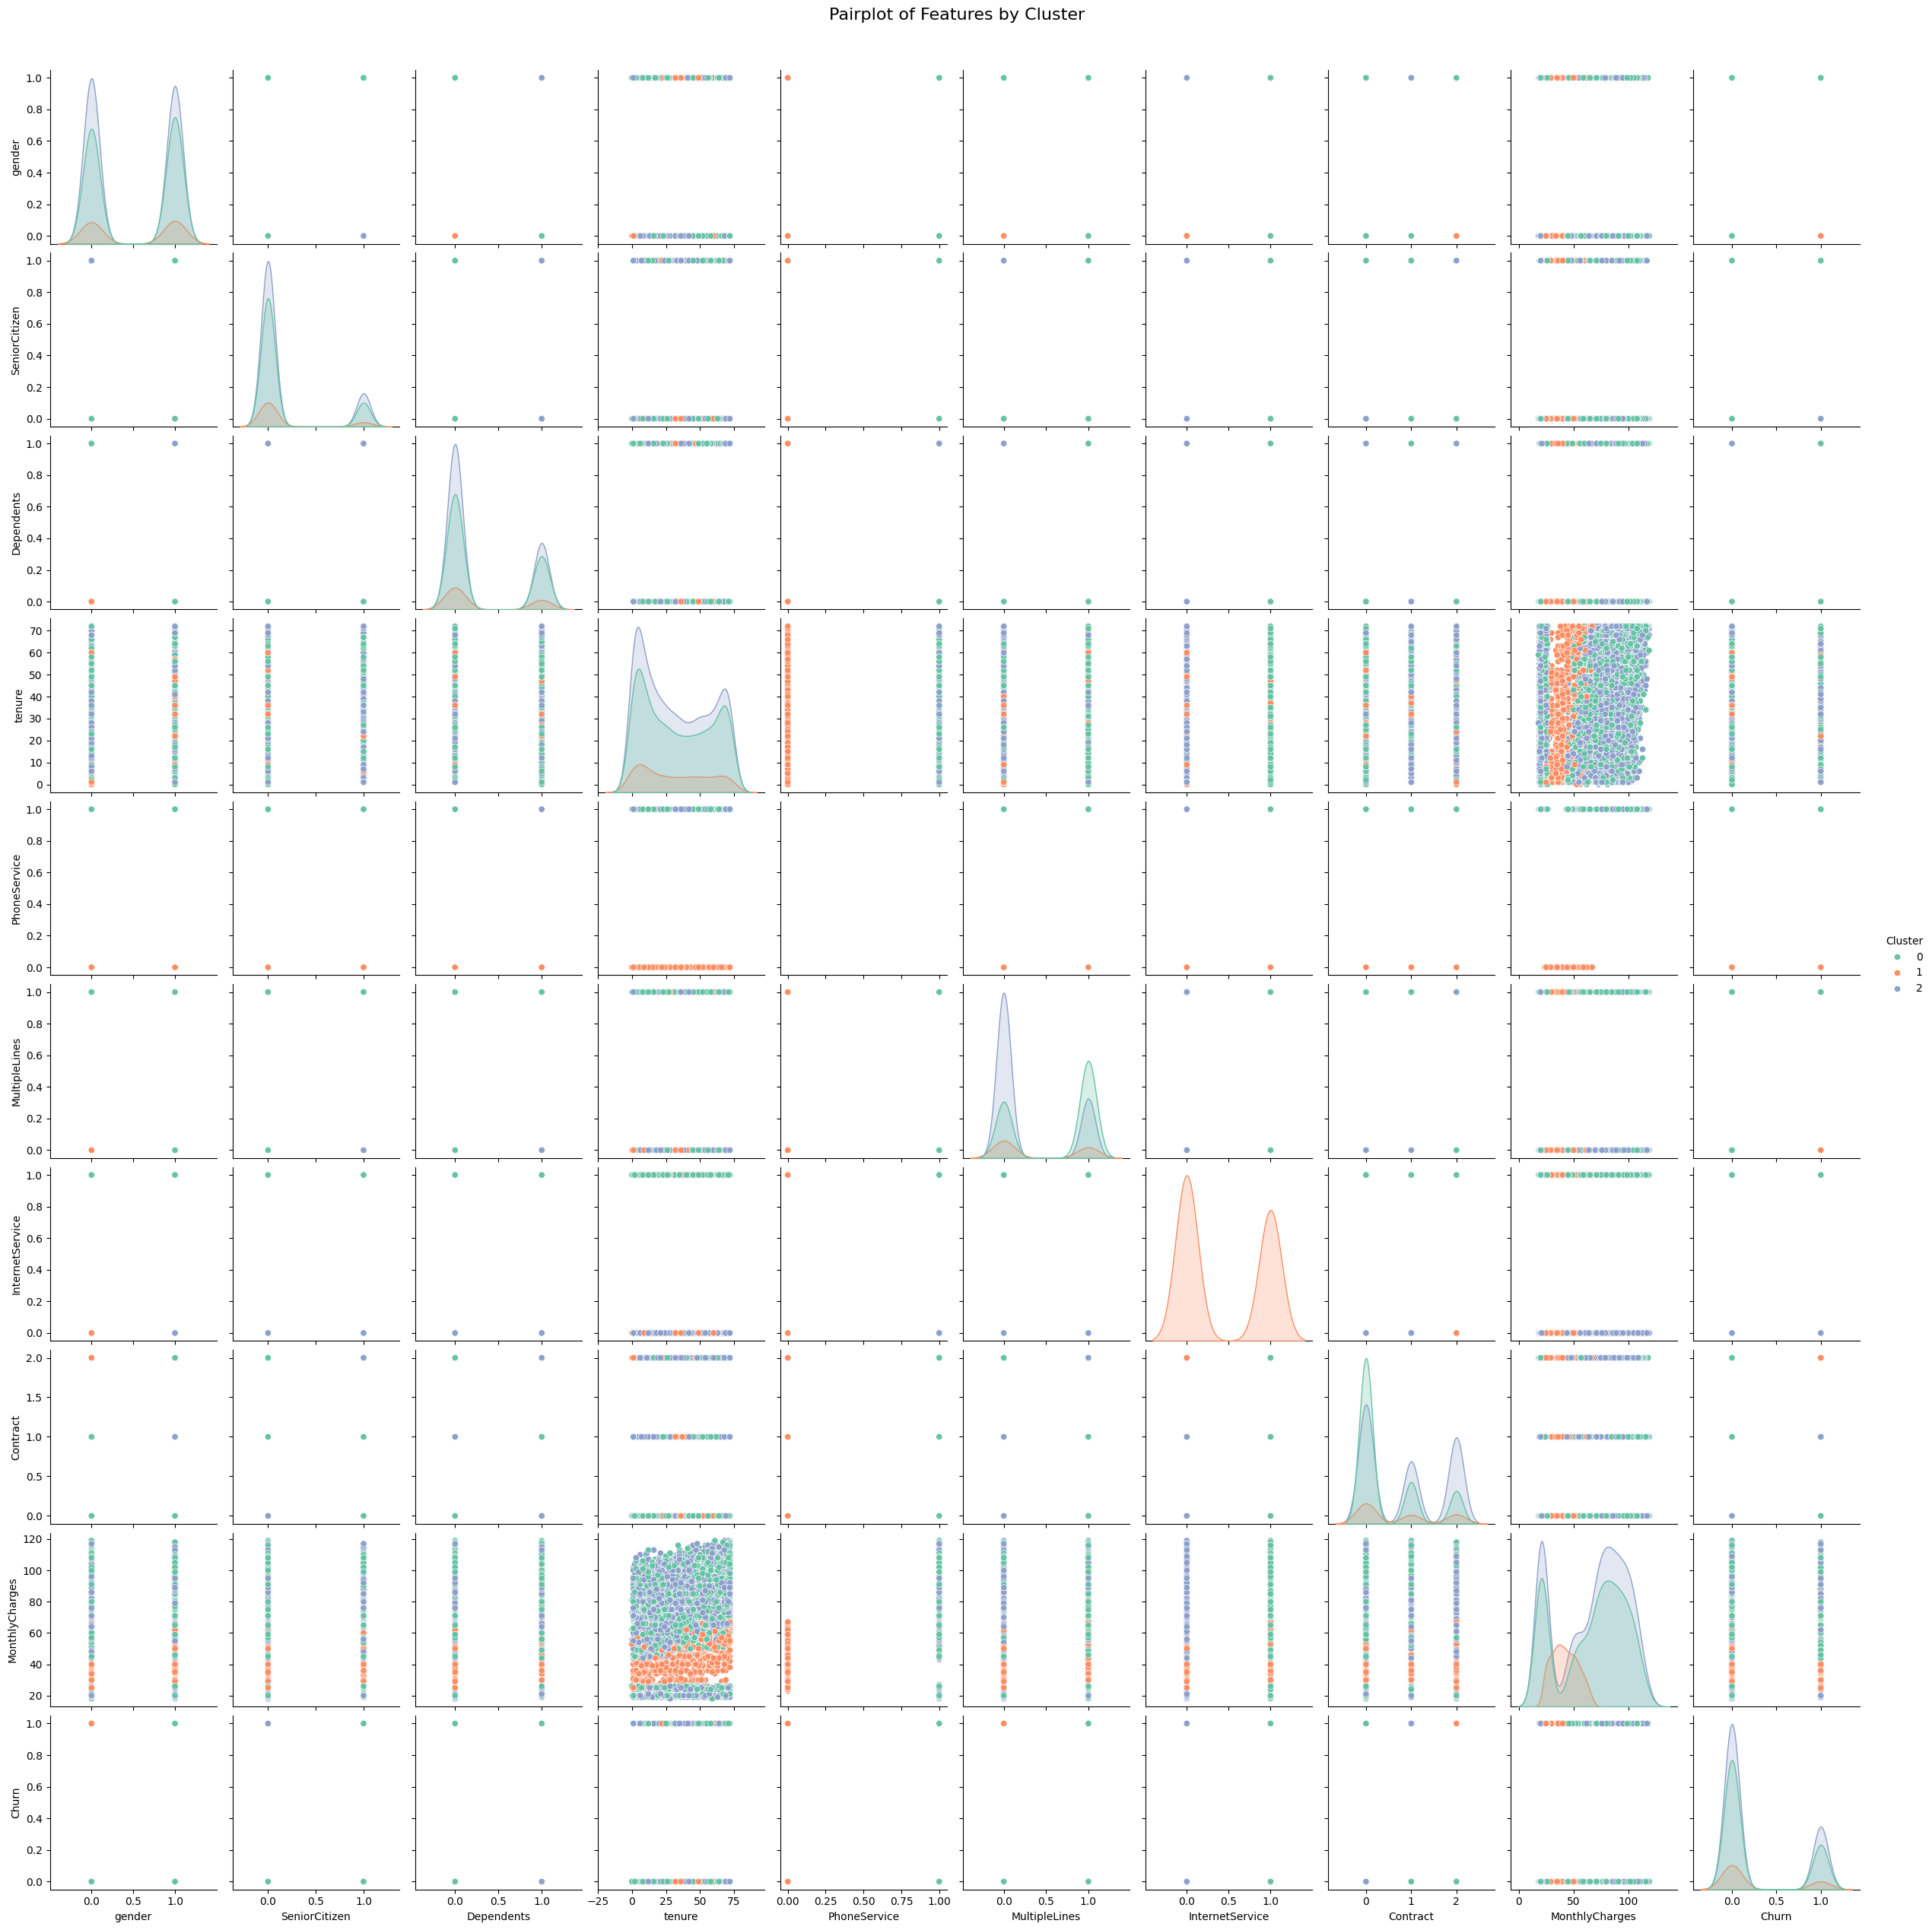

In [46]:
# ========================
# 10. Cluster Visualization (Pairplot)
# ========================

# Visualize the clusters using a pairplot (showing relationships between pairs of features)
sns.pairplot(df, hue='Cluster', vars=df.columns[:-1], palette='Set2')
plt.suptitle("Pairplot of Features by Cluster", y=1.02, fontsize=16)
plt.show()

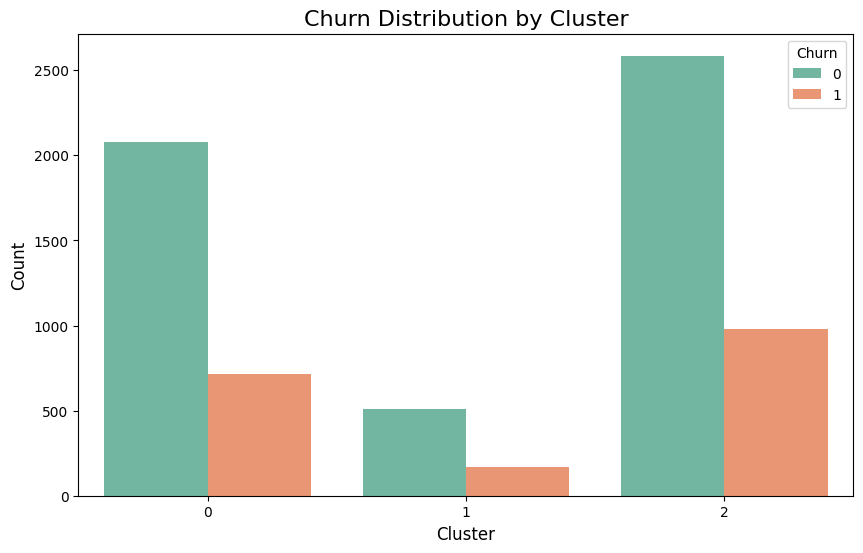

In [47]:
# ========================
# 12. Visualize Churn by Cluster
# ========================

# Visualize churn distribution by cluster
plt.figure(figsize=(10, 6))
sns.countplot(x='Cluster', hue='Churn', data=df, palette='Set2')
plt.title("Churn Distribution by Cluster", fontsize=16)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Churn', loc='upper right')
plt.show()



Churn Rate by Cluster:
Churn           0         1
Cluster                    
0        0.743113  0.256887
1        0.750733  0.249267
2        0.724902  0.275098

High-Risk Customers (Cluster 0):
Total high-risk customers: 2795

Retention Strategy for High-Risk Cluster:
1. Target with personalized offers or discounts.
2. Send customized emails emphasizing benefits for long-term customers.
3. Consider loyalty programs for long-term retention.


/tmp/ipython-input-3784591908.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=high_risk_cluster, palette='Set2')


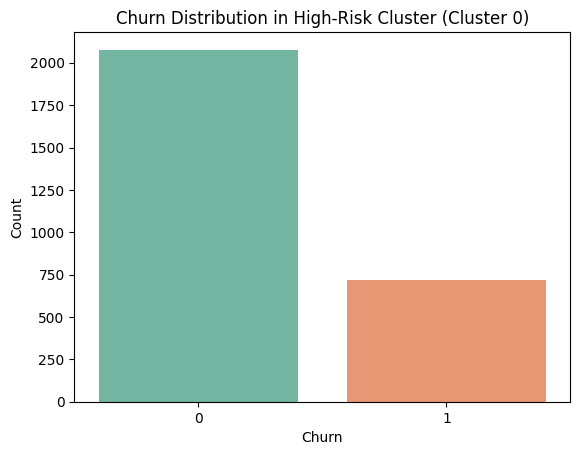

In [48]:
# ========================
# 1. Business Strategy: Churn Analysis by Cluster
# ========================

# Grouping by cluster and analyzing churn rates
cluster_churn = df.groupby('Cluster')['Churn'].value_counts(normalize=True).unstack().fillna(0)
print("\nChurn Rate by Cluster:")
print(cluster_churn)

# Identifying High-Risk / High-Value clusters (e.g., cluster with higher churn rates)
# Let's assume Cluster 0 has the highest churn rate; we can target this cluster with retention strategies
high_risk_cluster = df[df['Cluster'] == 0]

# Display strategy based on cluster
print(f"\nHigh-Risk Customers (Cluster 0):")
print(f"Total high-risk customers: {high_risk_cluster.shape[0]}")

# Business strategy for high-risk, high-value customers
print("\nRetention Strategy for High-Risk Cluster:")
print("1. Target with personalized offers or discounts.")
print("2. Send customized emails emphasizing benefits for long-term customers.")
print("3. Consider loyalty programs for long-term retention.")

# Example: Show the distribution of churn in high-risk cluster
sns.countplot(x='Churn', data=high_risk_cluster, palette='Set2')
plt.title("Churn Distribution in High-Risk Cluster (Cluster 0)")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()


In [49]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Prepare the data (use all columns except 'Churn' for features)
X = df.drop('Churn', axis=1)  # Features
y = df['Churn']  # Target variable (Churn)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Total samples:", len(df))
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nOverall Churn Distribution:")
print(y.value_counts(normalize=True))

print("\nTraining Churn Distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting Churn Distribution:")
print(y_test.value_counts(normalize=True))

# Feature scaling for ANN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaled Feature Means (Train):")
print(np.mean(X_train_scaled, axis=0))

print("\nScaled Feature Std (Train):")
print(np.std(X_train_scaled, axis=0))

# ========================
# 7. ANN Model with Improved Architecture
# ========================

# Build the ANN model with improvements
model = Sequential()

# Add input layer with batch normalization
model.add(Dense(units=512, activation='relu', input_dim=X_train_scaled.shape[1]))  # Increased neurons in the first hidden layer
model.add(BatchNormalization())  # Batch Normalization
model.add(Dropout(0.5))  # Dropout to reduce overfitting (increased rate)

# Add a second hidden layer with more neurons
model.add(Dense(units=256, activation='relu'))  # Increased neurons in the second hidden layer
model.add(BatchNormalization())  # Batch Normalization
model.add(Dropout(0.5))  # Dropout to reduce overfitting (increased rate)

# Add a third hidden layer with more neurons
model.add(Dense(units=128, activation='relu'))  # Third hidden layer with more neurons
model.add(BatchNormalization())  # Batch Normalization
model.add(Dropout(0.5))  # Dropout to reduce overfitting

# Add output layer for binary classification (Churn prediction)
model.add(Dense(units=1, activation='sigmoid'))  # Sigmoid for binary classification (0 or 1)

# Compile the model with Adam optimizer (with learning rate decay)
optimizer = Adam(learning_rate=0.0001)  # Even lower learning rate for better convergence
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# ========================
# Early Stopping Callback
# ========================
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Train the model with class weights (if needed) and early stopping
history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=10,
                    validation_data=(X_test_scaled, y_test),
                    callbacks=[early_stopping])


Total samples: 7043
Training samples: 5634
Testing samples: 1409

Overall Churn Distribution:
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

Training Churn Distribution:
Churn
0    0.733404
1    0.266596
Name: proportion, dtype: float64

Testing Churn Distribution:
Churn
0    0.739532
1    0.260468
Name: proportion, dtype: float64

Scaled Feature Means (Train):
[ 1.51340306e-17 -4.19338764e-17 -1.26116922e-18  1.13505229e-16
  1.07199383e-16 -2.90068919e-17 -4.03574149e-17  5.54914455e-17
 -6.49502146e-17 -1.03415876e-16]

Scaled Feature Std (Train):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.5501 - loss: 0.9636 - val_accuracy: 0.7410 - val_loss: 0.5285
Epoch 2/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6467 - loss: 0.7366 - val_accuracy: 0.7559 - val_loss: 0.5059
Epoch 3/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6871 - loss: 0.6603 - val_accuracy: 0.7615 - val_loss: 0.4903
Epoch 4/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6905 - loss: 0.6343 - val_accuracy: 0.7573 - val_loss: 0.4872
Epoch 5/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7098 - loss: 0.6028 - val_accuracy: 0.7644 - val_loss: 0.4889
Epoch 6/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7173 - loss: 0.6072 - val_accuracy: 0.7615 - val_loss: 0.4849
Epoch 7/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7129 - loss: 0.6002 - val_accuracy: 0.7630 - val_loss: 0.4805
Epoch 8/100
564/564 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7281 - loss: 0.5658 - val_accu

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7647 - loss: 0.4584

Test Accuracy: 0.7622


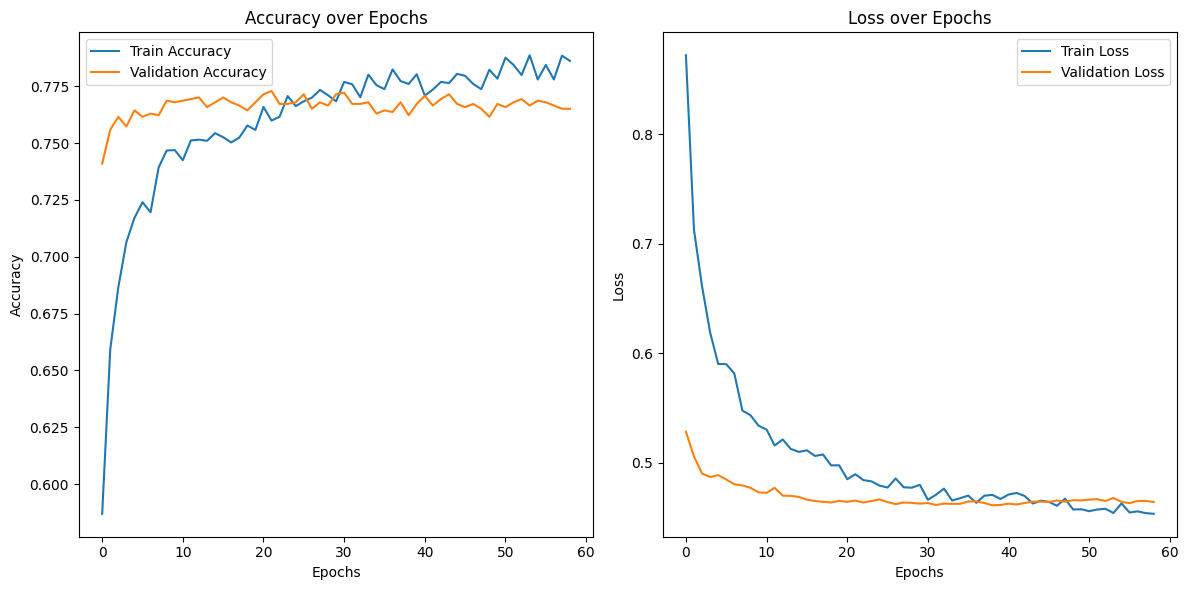

In [50]:
# ========================
# 8. Model Evaluation
# ========================

# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test_scaled, y_test)
print(f"\nTest Accuracy: {test_acc:.4f}")

# Plot training & validation accuracy/loss curves
plt.figure(figsize=(12, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7647 - loss: 0.4584

Test Accuracy: 0.7622
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


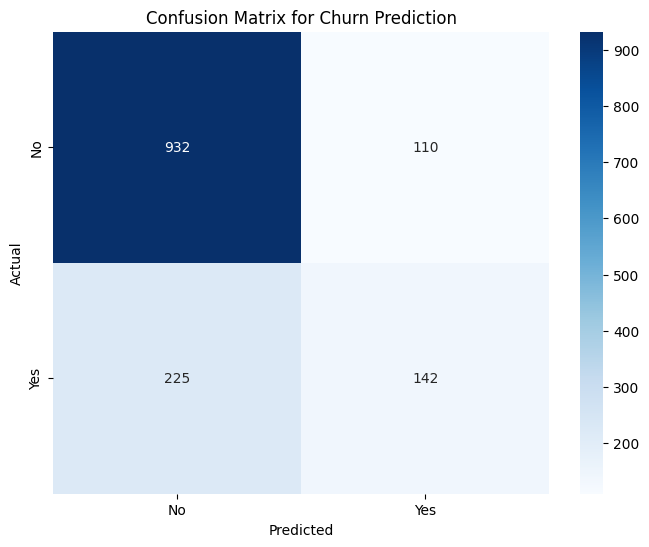


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.81      0.89      0.85      1042
       Churn       0.56      0.39      0.46       367

    accuracy                           0.76      1409
   macro avg       0.68      0.64      0.65      1409
weighted avg       0.74      0.76      0.75      1409



In [51]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# ========================
# 11. Model Evaluation
# ========================

# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test_scaled, y_test)
print(f"\nTest Accuracy: {test_acc:.4f}")

# ========================
# Confusion Matrix
# ========================

# Predict the churn labels for the test set
y_pred = model.predict(X_test_scaled)
y_pred = (y_pred > 0.5).astype(int)  # Convert probabilities to binary (0 or 1)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title("Confusion Matrix for Churn Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ========================
# Classification Report
# ========================

# Print classification report (Precision, Recall, F1-Score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))


In [52]:
df_ohe = pd.get_dummies(
    df,
    columns=['gender', 'PhoneService', 'MultipleLines',
             'InternetService', 'Contract', 'Dependents'],
    drop_first=True
)

X = df_ohe.drop('Churn', axis=1)
y = df_ohe['Churn']


In [53]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)


{0: np.float64(0.6817521781219749), 1: np.float64(1.8754993342210386)}


45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


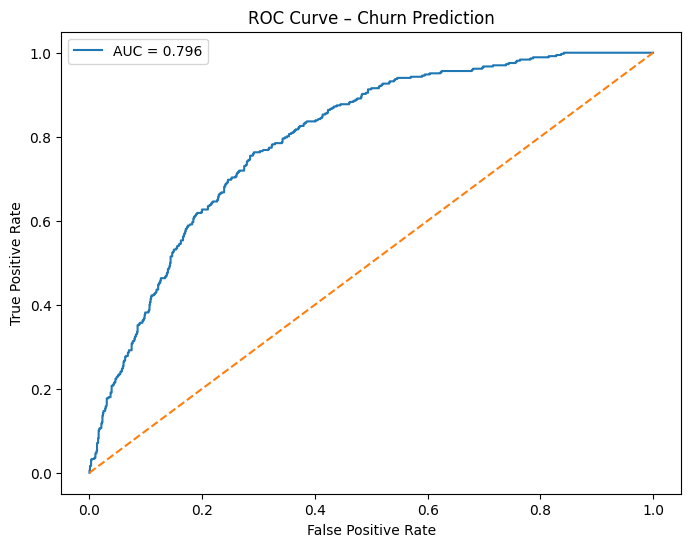

In [54]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict(X_test_scaled)

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Churn Prediction')
plt.legend()
plt.show()




In [55]:
threshold = 0.4
y_pred_custom = (y_prob > threshold).astype(int)

print(classification_report(y_test, y_pred_custom))


              precision    recall  f1-score   support

           0       0.84      0.83      0.84      1042
           1       0.54      0.56      0.55       367

    accuracy                           0.76      1409
   macro avg       0.69      0.70      0.69      1409
weighted avg       0.76      0.76      0.76      1409



In [56]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Total samples:", len(df))
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nOverall Churn Distribution:")
print(y.value_counts(normalize=True))

print("\nTraining Churn Distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting Churn Distribution:")
print(y_test.value_counts(normalize=True))

# Feature scaling for ANN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaled Feature Means (Train):")
print(np.mean(X_train_scaled, axis=0))

print("\nScaled Feature Std (Train):")
print(np.std(X_train_scaled, axis=0))

# ========================
# 7. ANN Model with Improved Architecture
# ========================

# Build the ANN model with improvements
model = Sequential()

# Add input layer with batch normalization
model.add(Dense(units=512, activation='relu', input_dim=X_train_scaled.shape[1]))  # Increased neurons in the first hidden layer
model.add(BatchNormalization())  # Batch Normalization
model.add(Dropout(0.5))  # Dropout to reduce overfitting (increased rate)

# Add a second hidden layer with more neurons
model.add(Dense(units=256, activation='relu'))  # Increased neurons in the second hidden layer
model.add(BatchNormalization())  # Batch Normalization
model.add(Dropout(0.5))  # Dropout to reduce overfitting (increased rate)

# Add a third hidden layer with more neurons
model.add(Dense(units=128, activation='relu'))  # Third hidden layer with more neurons
model.add(BatchNormalization())  # Batch Normalization
model.add(Dropout(0.5))  # Dropout to reduce overfitting

# Add output layer for binary classification (Churn prediction)
model.add(Dense(units=1, activation='sigmoid'))  # Sigmoid for binary classification (0 or 1)

# Compile the model with Adam optimizer (with learning rate decay)
optimizer = Adam(learning_rate=0.0001)  # Even lower learning rate for better convergence
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# ========================
# Early Stopping Callback
# ========================
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Train the model with class weights (if needed) and early stopping
history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=10,
                    validation_data=(X_test_scaled, y_test),
                    callbacks=[early_stopping])


Total samples: 7043
Training samples: 4930
Testing samples: 2113

Overall Churn Distribution:
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

Training Churn Distribution:
Churn
0    0.735497
1    0.264503
Name: proportion, dtype: float64

Testing Churn Distribution:
Churn
0    0.732608
1    0.267392
Name: proportion, dtype: float64

Scaled Feature Means (Train):
[ 1.33316842e-17  6.77393683e-17  1.16742316e-16 -2.59427368e-17
  6.48568420e-17  2.88252631e-18  2.26998947e-17 -2.16189473e-17
 -8.64757893e-18 -5.76505262e-18 -1.21066105e-16]

Scaled Feature Std (Train):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


493/493 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5687 - loss: 0.9354 - val_accuracy: 0.7515 - val_loss: 0.5012
Epoch 2/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6253 - loss: 0.7876 - val_accuracy: 0.7638 - val_loss: 0.4863
Epoch 3/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6607 - loss: 0.7080 - val_accuracy: 0.7695 - val_loss: 0.4737
Epoch 4/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6944 - loss: 0.6514 - val_accuracy: 0.7733 - val_loss: 0.4676
Epoch 5/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6976 - loss: 0.6491 - val_accuracy: 0.7795 - val_loss: 0.4665
Epoch 6/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6971 - loss: 0.6271 - val_accuracy: 0.7799 - val_loss: 0.4645
Epoch 7/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7466 - loss: 0.5675 - val_accuracy: 0.7709 - val_loss: 0.4634
Epoch 8/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7403 - loss: 0.5673 - val_accuracy: 0.7743

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7698 - loss: 0.4603

Test Accuracy: 0.7733


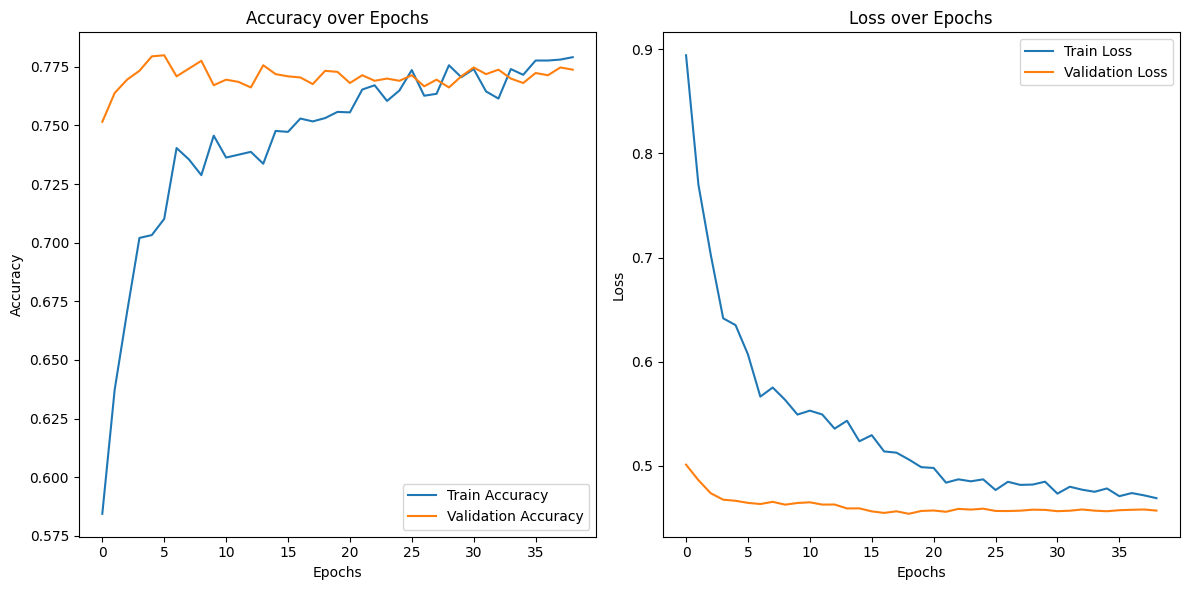

In [57]:
# ========================
# 8. Model Evaluation
# ========================

# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test_scaled, y_test)
print(f"\nTest Accuracy: {test_acc:.4f}")

# Plot training & validation accuracy/loss curves
plt.figure(figsize=(12, 6))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7698 - loss: 0.4603

Test Accuracy: 0.7733
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


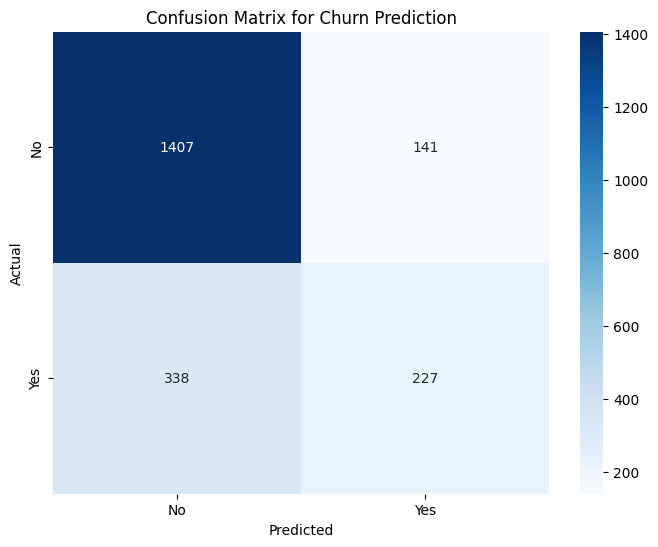


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.81      0.91      0.85      1548
       Churn       0.62      0.40      0.49       565

    accuracy                           0.77      2113
   macro avg       0.71      0.66      0.67      2113
weighted avg       0.76      0.77      0.76      2113



In [58]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# ========================
# 11. Model Evaluation
# ========================

# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test_scaled, y_test)
print(f"\nTest Accuracy: {test_acc:.4f}")

# ========================
# Confusion Matrix
# ========================

# Predict the churn labels for the test set
y_pred = model.predict(X_test_scaled)
y_pred = (y_pred > 0.5).astype(int)  # Convert probabilities to binary (0 or 1)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title("Confusion Matrix for Churn Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ========================
# Classification Report
# ========================

# Print classification report (Precision, Recall, F1-Score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))


In [59]:
df_ohe = pd.get_dummies(
    df,
    columns=['gender', 'PhoneService', 'MultipleLines',
             'InternetService', 'Contract', 'Dependents'],
    drop_first=True
)

X = df_ohe.drop('Churn', axis=1)
y = df_ohe['Churn']


In [60]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)


{0: np.float64(0.6798124655267512), 1: np.float64(1.8903374233128833)}


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


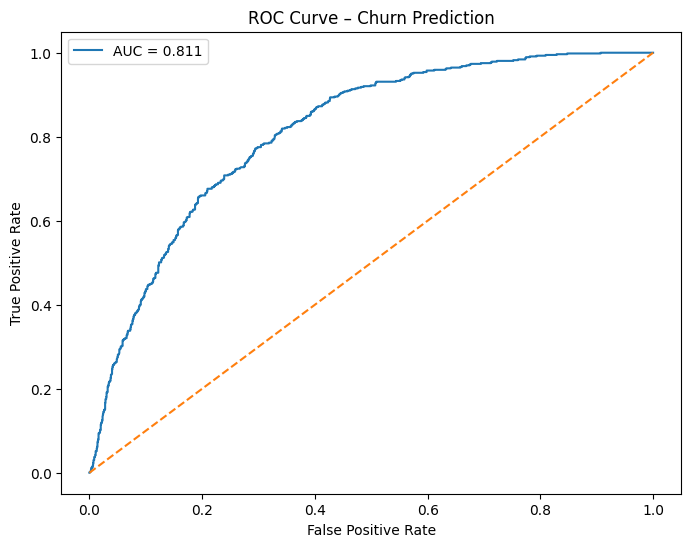

In [61]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict(X_test_scaled)

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Churn Prediction')
plt.legend()
plt.show()



In [62]:
threshold = 0.4
y_pred_custom = (y_prob > threshold).astype(int)

print(classification_report(y_test, y_pred_custom))


              precision    recall  f1-score   support

           0       0.84      0.85      0.84      1548
           1       0.57      0.56      0.57       565

    accuracy                           0.77      2113
   macro avg       0.71      0.71      0.71      2113
weighted avg       0.77      0.77      0.77      2113



Class Weights: {0: np.float64(0.6806146115191342), 1: np.float64(1.8841626538255751)}

Total samples: 7043
Training samples: 4930
Testing samples: 2113

Churn distribution (Overall):
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

Churn distribution (Train):
Churn
0    0.734686
1    0.265314
Name: proportion, dtype: float64

Churn distribution (Test):
Churn
0    0.734501
1    0.265499
Name: proportion, dtype: float64

Feature scaling check (first 5 features):
Means (should be ~0): [-2.26998947e-17  1.45567579e-16 -8.64757893e-18 -8.64757893e-18
  1.44126316e-18]
Stds  (should be ~1): [1. 1. 1. 1. 1.]
Epoch 1/100
155/155 - 4s - 26ms/step - accuracy: 0.5544 - loss: 0.9215 - val_accuracy: 0.7137 - val_loss: 0.6271
Epoch 2/100
155/155 - 1s - 7ms/step - accuracy: 0.6037 - loss: 0.8362 - val_accuracy: 0.7307 - val_loss: 0.5624
Epoch 3/100
155/155 - 1s - 8ms/step - accuracy: 0.6314 - loss: 0.7764 - val_accuracy: 0.7066 - val_loss: 0.5716
Epoch 4/100
155/155 - 1s - 8ms/step -

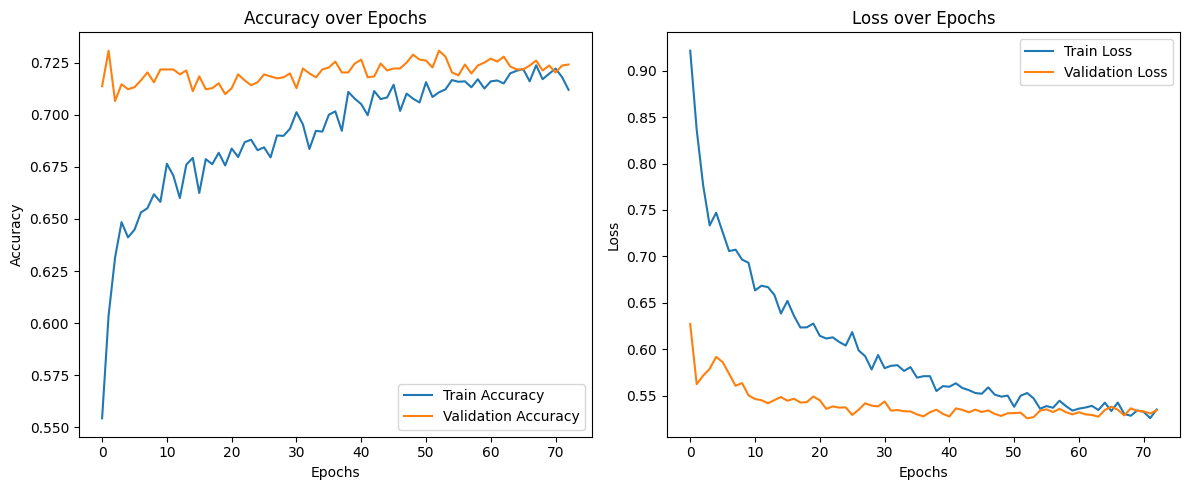

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


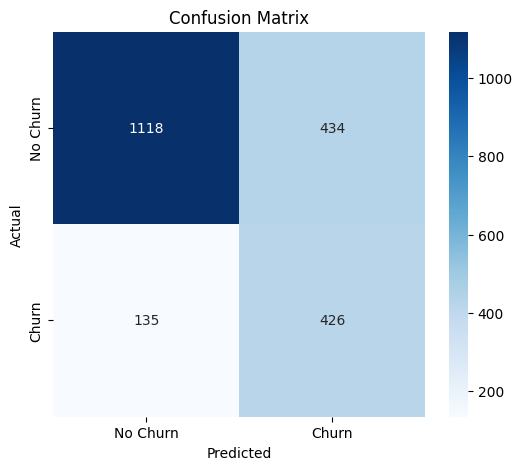


Classification Report (threshold = 0.5):
              precision    recall  f1-score   support

    No Churn       0.89      0.72      0.80      1552
       Churn       0.50      0.76      0.60       561

    accuracy                           0.73      2113
   macro avg       0.69      0.74      0.70      2113
weighted avg       0.79      0.73      0.74      2113



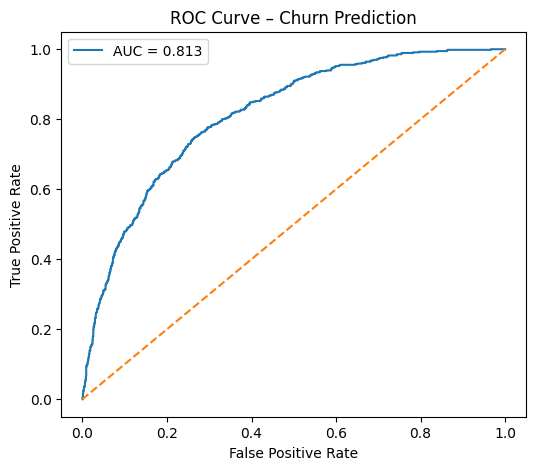


Classification Report (threshold = 0.4):
              precision    recall  f1-score   support

    No Churn       0.91      0.60      0.73      1552
       Churn       0.44      0.84      0.57       561

    accuracy                           0.67      2113
   macro avg       0.67      0.72      0.65      2113
weighted avg       0.79      0.67      0.69      2113



In [63]:
# ========================
# 0. Imports
# ========================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ========================
# 1. One-Hot Encode Categorical Variables
# ========================
df_ohe = pd.get_dummies(
    df,
    columns=['gender', 'PhoneService', 'MultipleLines',
             'InternetService', 'Contract', 'Dependents'],
    drop_first=True
)

X = df_ohe.drop('Churn', axis=1)
y = df_ohe['Churn']

# ========================
# 2. Compute Class Weights
# ========================
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y),
    y=y
)
class_weight_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weight_dict)

# ========================
# 3. Stratified Train-Test Split
# ========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"\nTotal samples: {len(df)}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

print("\nChurn distribution (Overall):")
print(y.value_counts(normalize=True))

print("\nChurn distribution (Train):")
print(y_train.value_counts(normalize=True))

print("\nChurn distribution (Test):")
print(y_test.value_counts(normalize=True))

# ========================
# 4. Feature Scaling
# ========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verify scaling
print("\nFeature scaling check (first 5 features):")
print("Means (should be ~0):", X_train_scaled[:, :5].mean(axis=0))
print("Stds  (should be ~1):", X_train_scaled[:, :5].std(axis=0))

# ========================
# 5. Build ANN Model
# ========================
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),  # Proper input layer
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(1, activation='sigmoid')  # Output
])

# Compile Model
optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# ========================
# 6. Early Stopping
# ========================
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# ========================
# 7. Train Model with Class Weights
# ========================
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping],
    verbose=2
)

# ========================
# 8. Evaluate Model
# ========================
# Test Accuracy & Loss
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")

# Training Curves
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.title('Accuracy over Epochs')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.title('Loss over Epochs')
plt.legend()
plt.tight_layout()
plt.show()

# ========================
# 9. Predictions & Metrics
# ========================
y_prob = model.predict(X_test_scaled)
threshold = 0.5
y_pred = (y_prob > threshold).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report (threshold = 0.5):")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curve – Churn Prediction')
plt.legend()
plt.show()

# ========================
# 10. Custom Threshold Example
# ========================
threshold_custom = 0.4
y_pred_custom = (y_prob > threshold_custom).astype(int)
print(f"\nClassification Report (threshold = {threshold_custom}):")
print(classification_report(y_test, y_pred_custom, target_names=['No Churn', 'Churn']))



Original dataset shape: Counter({0: 5174, 1: 1869})
Balanced dataset shape: Counter({1: 5174, 0: 5174})

Total samples (after SMOTE): 10348
Training samples: 7243
Testing samples: 3105

Churn distribution (Train):
Churn
1    0.500069
0    0.499931
Name: proportion, dtype: float64

Churn distribution (Test):
Churn
0    0.500161
1    0.499839
Name: proportion, dtype: float64

Feature scaling check (first 5 features):
Means (should be ~0): [ 7.35754593e-17  1.17720735e-17 -7.45564654e-17 -3.60519751e-17
 -4.36547725e-17]
Stds  (should be ~1): [1. 1. 1. 1. 1.]
Epoch 1/100
227/227 - 5s - 21ms/step - accuracy: 0.6207 - loss: 0.8137 - val_accuracy: 0.7359 - val_loss: 0.5532
Epoch 2/100
227/227 - 2s - 7ms/step - accuracy: 0.6883 - loss: 0.6967 - val_accuracy: 0.7758 - val_loss: 0.4763
Epoch 3/100
227/227 - 2s - 7ms/step - accuracy: 0.7056 - loss: 0.6532 - val_accuracy: 0.7797 - val_loss: 0.4707
Epoch 4/100
227/227 - 3s - 15ms/step - accuracy: 0.7206 - loss: 0.6185 - val_accuracy: 0.7842 - val

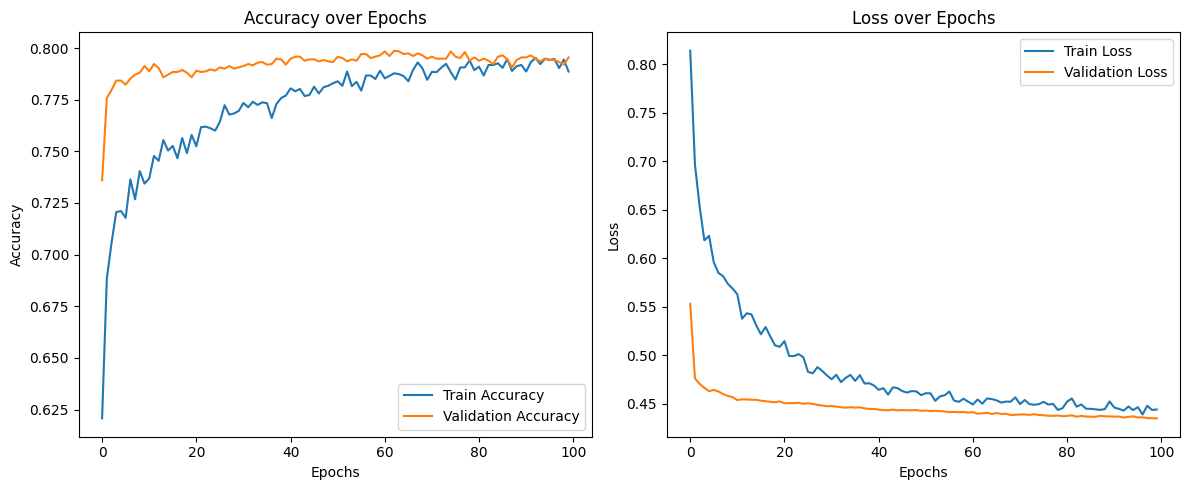

98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


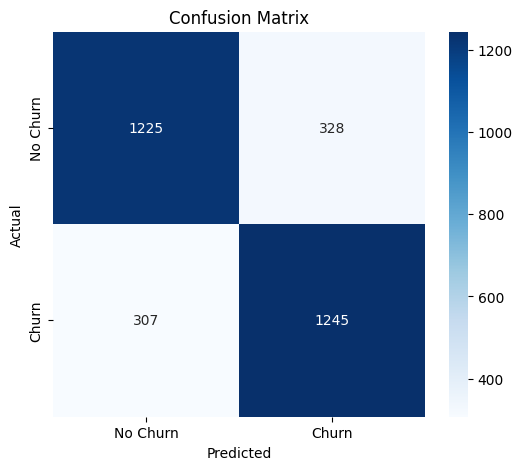


Classification Report (threshold = 0.5):
              precision    recall  f1-score   support

    No Churn       0.80      0.79      0.79      1553
       Churn       0.79      0.80      0.80      1552

    accuracy                           0.80      3105
   macro avg       0.80      0.80      0.80      3105
weighted avg       0.80      0.80      0.80      3105



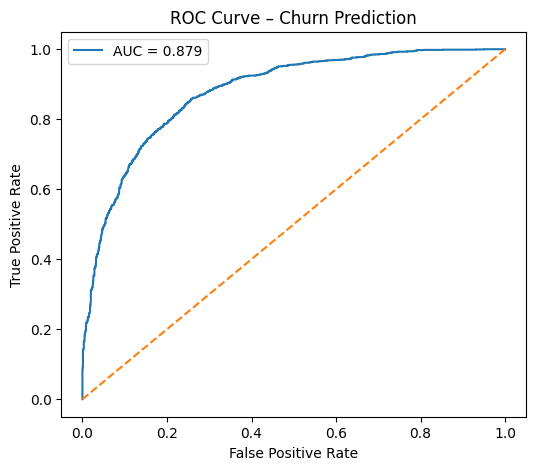


Classification Report (threshold = 0.4):
              precision    recall  f1-score   support

    No Churn       0.85      0.70      0.77      1553
       Churn       0.75      0.88      0.81      1552

    accuracy                           0.79      3105
   macro avg       0.80      0.79      0.79      3105
weighted avg       0.80      0.79      0.79      3105



In [64]:
# ========================
# 0. Imports
# ========================
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# For balancing
from imblearn.over_sampling import SMOTE

# ========================
# 1. One-Hot Encode Categorical Variables
# ========================
df_ohe = pd.get_dummies(
    df,
    columns=['gender', 'PhoneService', 'MultipleLines',
             'InternetService', 'Contract', 'Dependents'],
    drop_first=True
)

X = df_ohe.drop('Churn', axis=1)
y = df_ohe['Churn']

# ========================
# 2. Balance Dataset using SMOTE
# ========================
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

# Corrected class count printing
print(f"\nOriginal dataset shape: {Counter(y)}")
print(f"Balanced dataset shape: {Counter(y_balanced)}")

# ========================
# 3. Stratified Train-Test Split
# ========================
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.3, random_state=42, stratify=y_balanced
)

print(f"\nTotal samples (after SMOTE): {len(X_balanced)}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

print("\nChurn distribution (Train):")
print(y_train.value_counts(normalize=True))

print("\nChurn distribution (Test):")
print(y_test.value_counts(normalize=True))

# ========================
# 4. Feature Scaling
# ========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verify scaling
print("\nFeature scaling check (first 5 features):")
print("Means (should be ~0):", X_train_scaled[:, :5].mean(axis=0))
print("Stds  (should be ~1):", X_train_scaled[:, :5].std(axis=0))

# ========================
# 5. Build ANN Model
# ========================
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# ========================
# 6. Early Stopping
# ========================
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# ========================
# 7. Train Model
# ========================
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=2
)

# ========================
# 8. Evaluate Model
# ========================
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")

# Plot training curves
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.title('Loss over Epochs')
plt.legend()
plt.tight_layout()
plt.show()

# ========================
# 9. Predictions & Metrics
# ========================
y_prob = model.predict(X_test_scaled)
y_pred = (y_prob > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix")
plt.show()

print("\nClassification Report (threshold = 0.5):")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

roc_auc = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curve – Churn Prediction')
plt.legend()
plt.show()

# ========================
# 10. Custom Threshold Example
# ========================
threshold_custom = 0.4
y_pred_custom = (y_prob > threshold_custom).astype(int)
print(f"\nClassification Report (threshold = {threshold_custom}):")
print(classification_report(y_test, y_pred_custom, target_names=['No Churn', 'Churn']))


In [65]:
# ========================
# Save Full Model
# ========================
model.save("churn_ann_model.h5")   # HDF5 format

print("Model saved successfully!")


Model saved successfully!
